# Logistic Regression on Fatal Crashes 

# Modeling

In [8]:
# packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

                       Feature  Coefficient  Odds_Ratio
10          time_segment_Night     0.864997    2.374999
8         time_segment_Evening     0.616319    1.852097
6       time_segment_Afternoon     0.489169    1.630960
9      time_segment_Late Night     0.477232    1.611607
36              precinct_NORTH     0.384186    1.468418
2            WEEK_DAY_Saturday     0.364907    1.440380
33          precinct_HERMITAGE     0.358377    1.431005
3              WEEK_DAY_Sunday     0.286665    1.331978
37              precinct_SOUTH     0.249199    1.282998
0              WEEK_DAY_Friday     0.186940    1.205555
1              WEEK_DAY_Monday     0.175709    1.192091
20              MONTH_NAME_Oct     0.151117    1.163133
35      precinct_MIDTOWN HILLS     0.084933    1.088644
38               precinct_WEST     0.083118    1.086670
24                   YEAR_2013     0.047936    1.049103
28                   YEAR_2017     0.031861    1.032374
22                   YEAR_2011     0.023639    1

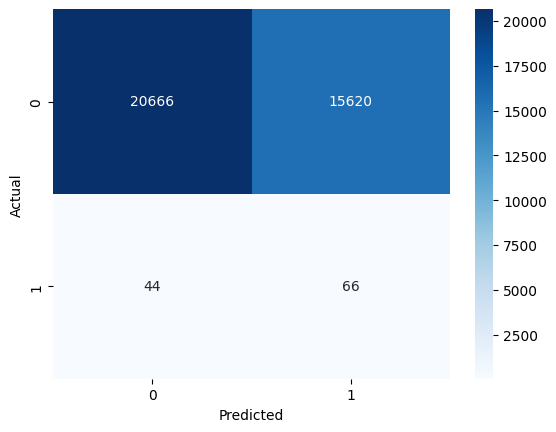

In [12]:
inflated_df = pd.read_csv("crash_inflated.csv")
X = pd.get_dummies(inflated_df[['WEEK_DAY', 'time_segment', 'MONTH_NAME', "YEAR", "precinct"]].astype(str))

# default drop dummies would have dropped central precinct and friday
# manually drop "average" columns, more valid baseline than default that can be interpreted as a "standard" or "normal" day/time segment
cols_to_drop = [
    'precinct_SOUTHEAST',      
    'WEEK_DAY_Tuesday',          
    'time_segment_Morning',
    'MONTH_NAME_Jan',
    'YEAR_2010'
]

X = X.drop(columns=cols_to_drop)
y = inflated_df['FATAL_CRASH']


# split into training and testing, build model
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_crash = LogisticRegression(class_weight = "balanced", max_iter=1000)
model_crash.fit(X_train_c, y_train_c)

# create a table that shows the odds ratio and coefficient for each feature
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_crash.coef_[0],
    'Odds_Ratio': np.exp(model_crash.coef_[0]) # coefficients are originally logged, exp to use for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)
feature_importance.to_csv("../results/Crash_feature_importance.csv", index=False)

# create confusion matrix of our model results
y_pred = model_crash.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../results/Crash_confusion_matrix.png")
plt.show()

In [72]:
# print classification report for our model
print(classification_report(y_test_c, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.57      0.73     36286
           1       0.00      0.60      0.01       110

    accuracy                           0.57     36396
   macro avg       0.50      0.58      0.37     36396
weighted avg       0.99      0.57      0.72     36396



In [73]:
# calculate roc-auc score 
from sklearn.metrics import roc_auc_score, roc_curve
y_probs = model_crash.predict_proba(X_test_c)[:,1]
auc_score = roc_auc_score(y_test_c, y_probs)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6133


## Graph the Odds Ratios of each feature

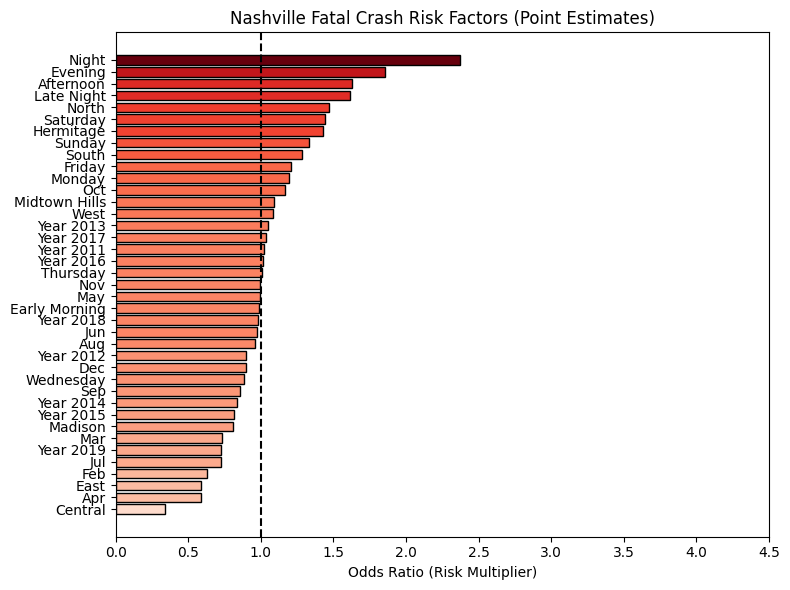

In [ ]:
plt.figure(figsize=(8,6))

feature_importance = feature_importance.sort_values("Odds_Ratio")
# rename display name so there are no raw variables
feature_importance['Display_Name'] = (feature_importance['Feature']
                             .str.replace('precinct_', '', case=False)
                             .str.replace('WEEK_DAY_', '', case=False)
                             .str.replace('MONTH_NAME_', '', case=False)
                             .str.replace('time_segment_', '', case=False)
                             .str.replace('_', ' ')
                             .str.title())
# red color theme to emphasize the high-risk zones
colors = plt.cm.Reds(feature_importance['Odds_Ratio'] / feature_importance['Odds_Ratio'].max())

# create horizontal bar plot of odds ratios
plt.barh(feature_importance['Display_Name'], feature_importance['Odds_Ratio'], color=colors, edgecolor='black')
# vertical line to show baseline
plt.axvline(x=1, color='black', linestyle='--', label='Baseline (No Effect)')


plt.xlabel('Odds Ratio (Risk Multiplier)')
plt.title('Nashville Fatal Crash Risk Factors (Point Estimates)')
plt.xlim(0, 4.5)
plt.tight_layout()
plt.savefig("../results/Crash_Odds_Ratios.png")
plt.show()